In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

In [60]:
df = pd.read_csv('../data/processed/weatherHistory_cleaned.csv')

In [61]:
df.describe()

,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Cloud_Cover,Pressure,year,month,day,hour,day_of_week
count,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000,96429.0,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000
mean,11.929692,10.851707,0.734902,10.812460,187.497506,10.347225,0.0,1003.232915,2011.000539,6.522633,15.730537,11.499891,2.999969
std,9.550492,10.695743,0.195466,6.913345,107.376423,4.192548,0.0,116.984300,3.162514,3.448851,8.800613,6.922049,1.999971
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2005.000000,1.000000,1.000000,0.000000,0.000000
25%,4.683333,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000,2008.000000,4.000000,8.000000,6.000000,1.000000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000,2011.000000,7.000000,16.000000,11.000000,3.000000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000,2014.000000,10.000000,23.000000,17.000000,5.000000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000,2016.000000,12.000000,31.000000,23.000000,6.000000


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96429 entries, 0 to 96428
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  96429 non-null  str    
 1   Summary               96429 non-null  str    
 2   Precip_Type           96429 non-null  str    
 3   Temperature           96429 non-null  float64
 4   Apparent_Temperature  96429 non-null  float64
 5   Humidity              96429 non-null  float64
 6   Wind_Speed            96429 non-null  float64
 7   Wind_Bearing          96429 non-null  float64
 8   Visibility            96429 non-null  float64
 9   Cloud_Cover           96429 non-null  float64
 10  Pressure              96429 non-null  float64
 11  Daily_Summary         96429 non-null  str    
 12  year                  96429 non-null  int64  
 13  month                 96429 non-null  int64  
 14  day                   96429 non-null  int64  
 15  hour                  96429 no

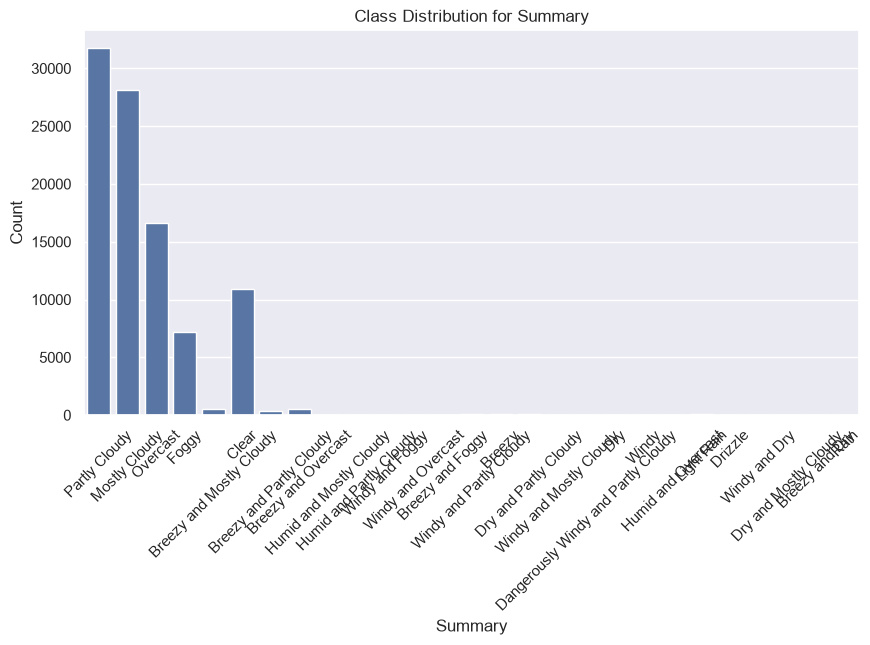

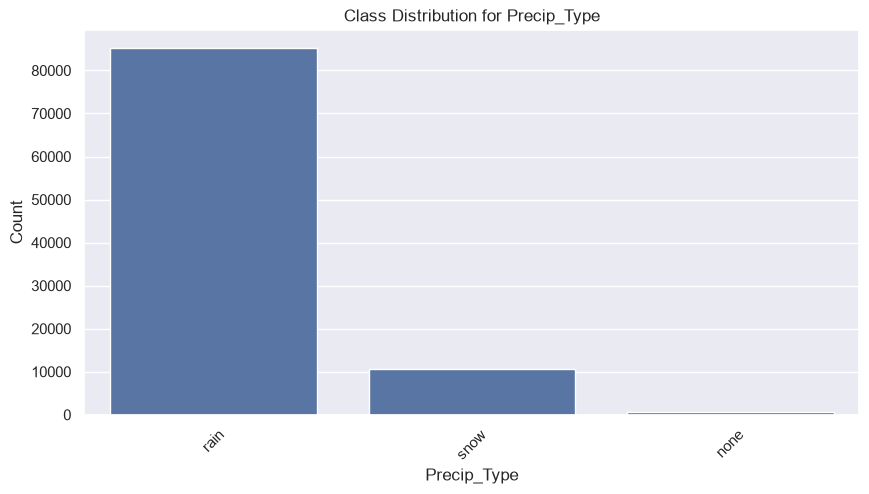

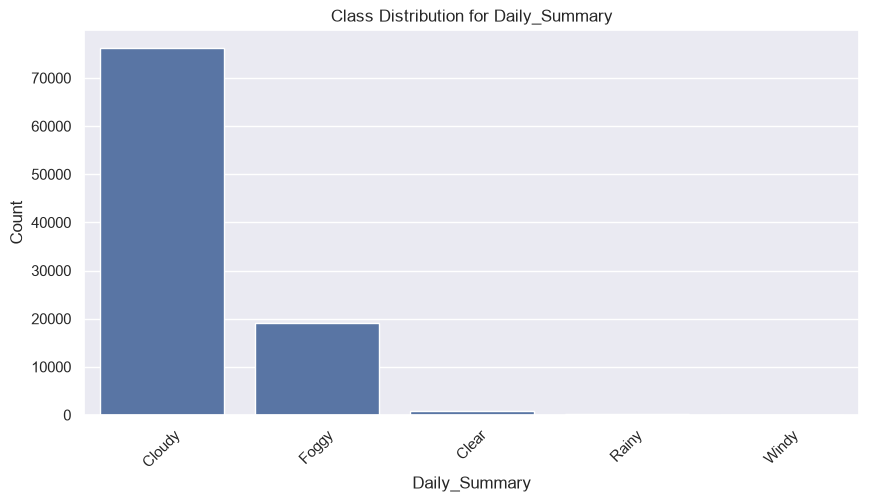

In [63]:
categorical_cols = ['Summary', 'Precip_Type', 'Daily_Summary']

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col)

    plt.title(f"Class Distribution for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

In [64]:
df = pd.get_dummies(df, columns=['Precip_Type'], drop_first=True)

In [65]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
ct = ColumnTransformer([('precip', ohe, ['Precip_Type'])], remainder='passthrough')

In [66]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [67]:
df['suitability'] = df['suitability'].map({'Suitable': 1, 'Not Suitable': 0})
df.head()

,Date,Summary,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Cloud_Cover,Pressure,...,year,month,day,hour,day_of_week,suitability,Precip_Type_rain,Precip_Type_snow,hour_sin,hour_cos
0,2006-03-31 22:00:00+00:00,Partly Cloudy,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,...,2006,3,31,22,4,0,True,False,-0.500000,0.866025
1,2006-03-31 23:00:00+00:00,Partly Cloudy,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,...,2006,3,31,23,4,0,True,False,-0.258819,0.965926
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,...,2006,4,1,0,5,0,True,False,0.000000,1.000000
3,2006-04-01 01:00:00+00:00,Partly Cloudy,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,...,2006,4,1,1,5,0,True,False,0.258819,0.965926
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,...,2006,4,1,2,5,0,True,False,0.500000,0.866025


In [68]:
counts = df['Summary'].value_counts()
rare = counts[counts < 20].index
df['Summary'] = df['Summary'].replace(rare, 'Other')

df = pd.get_dummies(df, columns=['Summary'], drop_first=True)
df.head()

,Date,Temperature,Apparent_Temperature,Humidity,Wind_Speed,Wind_Bearing,Visibility,Cloud_Cover,Pressure,Daily_Summary,...,Summary_Foggy,Summary_Humid and Mostly Cloudy,Summary_Light Rain,Summary_Mostly Cloudy,Summary_Other,Summary_Overcast,Summary_Partly Cloudy,Summary_Windy and Mostly Cloudy,Summary_Windy and Overcast,Summary_Windy and Partly Cloudy
0,2006-03-31 22:00:00+00:00,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Cloudy,...,False,False,False,False,False,False,True,False,False,False
1,2006-03-31 23:00:00+00:00,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Cloudy,...,False,False,False,False,False,False,True,False,False,False
2,2006-04-01 00:00:00+00:00,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Cloudy,...,False,False,False,True,False,False,False,False,False,False
3,2006-04-01 01:00:00+00:00,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Cloudy,...,False,False,False,False,False,False,True,False,False,False
4,2006-04-01 02:00:00+00:00,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Cloudy,...,False,False,False,True,False,False,False,False,False,False


In [69]:
df.to_csv("../data/processed/weatherHistory_configured.csv", index=False)

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [72]:
df['suitability'] = (
    (df['Temperature'] > 18) &
    (df['Temperature'] < 32) &
    (df['Humidity'] < 0.80) &
    (df['Wind_Speed'] < 20) &
    (df['Precip_Type_rain'] == 0) &
    (df['Precip_Type_snow'] == 0)
).astype(int)

In [73]:
X = df.drop(
    columns=['Date', 'Daily_Summary', 'suitability']
)

y = df['suitability']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96429, 35)
y shape: (96429,)


In [74]:
print(X.isnull().sum().sum())

0


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (77143, 35)
X_test : (19286, 35)
y_train: (77143,)
y_test : (19286,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            class_weight='balanced'
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    )
}

In [105]:
# Get Logistic Regression model
logistic_model = models['Logistic Regression']

# Train
logistic_model.fit(X_train, y_train)

# Get probability of Suitability = 1
probability = logistic_model.predict_proba(X_test)[:, 1]

# Display first 20 probabilities
print(probability[:20])

[8.21093090e-11 7.74063589e-16 2.96440716e-12 6.16421875e-13
 1.21352700e-14 8.73817134e-21 9.74384471e-11 3.43304589e-07
 1.18248224e-07 2.55490321e-16 2.43978378e-14 1.71674591e-15
 3.42404474e-13 1.97268687e-17 1.03183943e-18 4.26619710e-16
 9.52100791e-11 2.95415246e-05 2.19747646e-14 1.04428516e-14]


In [112]:
threshold = 0.0000001

y_pred = (probability >= threshold).astype(int)

print(y_pred[:20])

[0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0]


In [113]:
print("Minimum:", probability.min())
print("Maximum:", probability.max())

Minimum: 2.186248262426888e-27
Maximum: 0.9999984208652591


In [114]:
print(pd.Series(probability).describe())

count    1.928600e+04
mean     7.942501e-04
std      2.413399e-02
min      2.186248e-27
25%      2.397891e-17
50%      2.853314e-14
75%      7.250135e-11
max      9.999984e-01
dtype: float64


In [115]:
for threshold in [0.5, 0.1, 0.01, 0.001, 0.0001, 0.000001, 0.0000001]:
    y_pred = (probability >= threshold).astype(int)

    print(
        f"Threshold = {threshold:.7f} | "
        f"Suitable = {(y_pred == 1).sum()} | "
        f"Not Suitable = {(y_pred == 0).sum()}"
    )

Threshold = 0.5000000 | Suitable = 12 | Not Suitable = 19274
Threshold = 0.1000000 | Suitable = 24 | Not Suitable = 19262
Threshold = 0.0100000 | Suitable = 70 | Not Suitable = 19216
Threshold = 0.0010000 | Suitable = 177 | Not Suitable = 19109
Threshold = 0.0001000 | Suitable = 363 | Not Suitable = 18923
Threshold = 0.0000010 | Suitable = 1180 | Not Suitable = 18106
Threshold = 0.0000001 | Suitable = 1791 | Not Suitable = 17495


In [116]:
print(probability[:20])
print(probability.min())
print(probability.max())
print(pd.Series(probability).describe())

[8.21093090e-11 7.74063589e-16 2.96440716e-12 6.16421875e-13
 1.21352700e-14 8.73817134e-21 9.74384471e-11 3.43304589e-07
 1.18248224e-07 2.55490321e-16 2.43978378e-14 1.71674591e-15
 3.42404474e-13 1.97268687e-17 1.03183943e-18 4.26619710e-16
 9.52100791e-11 2.95415246e-05 2.19747646e-14 1.04428516e-14]
2.186248262426888e-27
0.9999984208652591
count    1.928600e+04
mean     7.942501e-04
std      2.413399e-02
min      2.186248e-27
25%      2.397891e-17
50%      2.853314e-14
75%      7.250135e-11
max      9.999984e-01
dtype: float64


In [ ]:
for name, model in models.items():

    model.fit(X_train, y_train)

    print(name, "trained successfully")

Logistic Regression trained successfully
KNN trained successfully
Decision Tree trained successfully
SVM trained successfully
Random Forest trained successfully


In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        'F1': f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.999637,0.416667,1.0,0.588235
1,KNN,0.999896,1.000000,0.6,0.750000
2,Decision Tree,0.999948,1.000000,0.8,0.888889
3,SVM,0.999741,0.500000,1.0,0.666667
4,Random Forest,0.999948,1.000000,0.8,0.888889


In [79]:
results_df.sort_values(
    by='F1',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
2,Decision Tree,0.999948,1.000000,0.8,0.888889
4,Random Forest,0.999948,1.000000,0.8,0.888889
1,KNN,0.999896,1.000000,0.6,0.750000
3,SVM,0.999741,0.500000,1.0,0.666667
0,Logistic Regression,0.999637,0.416667,1.0,0.588235


In [80]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='f1',
        n_jobs=-1
    )

    cv_results.append({
        'Model': name,
        'CV_F1_Mean': scores.mean(),
        'CV_F1_STD': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by='CV_F1_Mean',
    ascending=False
)

,Model,CV_F1_Mean,CV_F1_STD
2,Decision Tree,0.949206,0.063014
4,Random Forest,0.876190,0.122706
3,SVM,0.605501,0.038743
1,KNN,0.413333,0.223706
0,Logistic Regression,0.378437,0.040756


In [81]:
best_model_name = cv_results_df.loc[
    cv_results_df['CV_F1_Mean'].idxmax(),
    'Model'
]

print("Best Model:", best_model_name)

Best Model: Decision Tree


In [82]:
best_model = models[best_model_name]

In [83]:
best_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_f

In [86]:
import joblib

joblib.dump(
    best_model,
    '../model/weather_suitability_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    # Predict test data
    y_pred = model.predict(X_test)

    # Calculate metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.999637,0.416667,1.0,0.588235
1,KNN,0.999896,1.000000,0.6,0.750000
2,Decision Tree,0.999948,1.000000,0.8,0.888889
3,SVM,0.999741,0.500000,1.0,0.666667
4,Random Forest,0.999948,1.000000,0.8,0.888889


In [88]:
results_df.sort_values(
    by='F1 Score',
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.999948,1.000000,0.8,0.888889
1,Random Forest,0.999948,1.000000,0.8,0.888889
2,KNN,0.999896,1.000000,0.6,0.750000
3,SVM,0.999741,0.500000,1.0,0.666667
4,Logistic Regression,0.999637,0.416667,1.0,0.588235


In [89]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['Not Suitable', 'Suitable'],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

Not Suitable       1.00      1.00      1.00     19281
    Suitable       0.42      1.00      0.59         5

    accuracy                           1.00     19286
   macro avg       0.71      1.00      0.79     19286
weighted avg       1.00      1.00      1.00     19286

KNN
              precision    recall  f1-score   support

Not Suitable       1.00      1.00      1.00     19281
    Suitable       1.00      0.60      0.75         5

    accuracy                           1.00     19286
   macro avg       1.00      0.80      0.87     19286
weighted avg       1.00      1.00      1.00     19286

Decision Tree
              precision    recall  f1-score   support

Not Suitable       1.00      1.00      1.00     19281
    Suitable       1.00      0.80      0.89         5

    accuracy                           1.00     19286
   macro avg       1.00      0.90      0.94     19286
weighted avg       1.00      1.00   

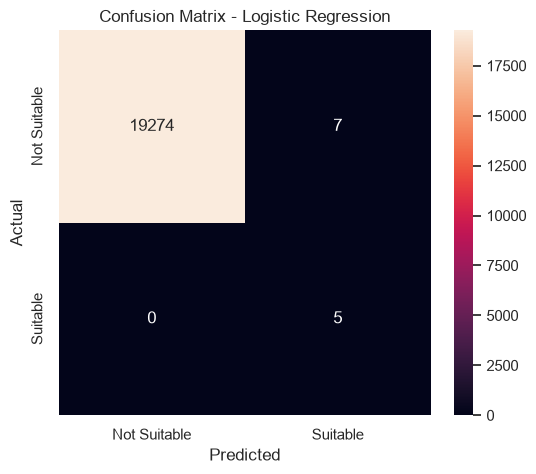

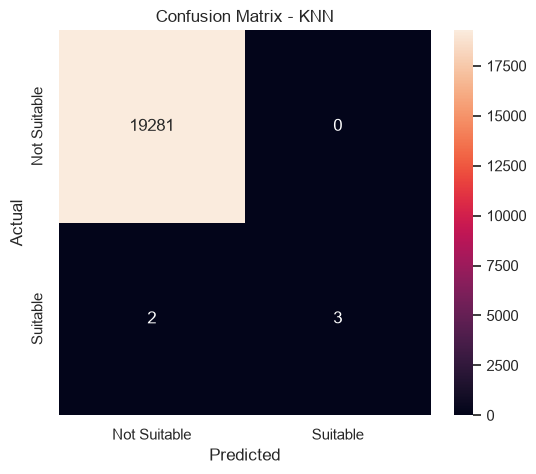

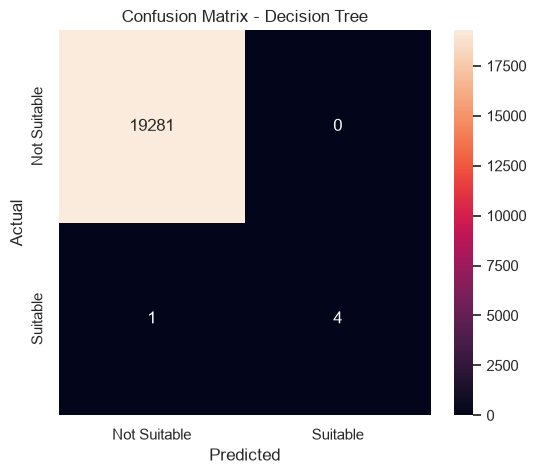

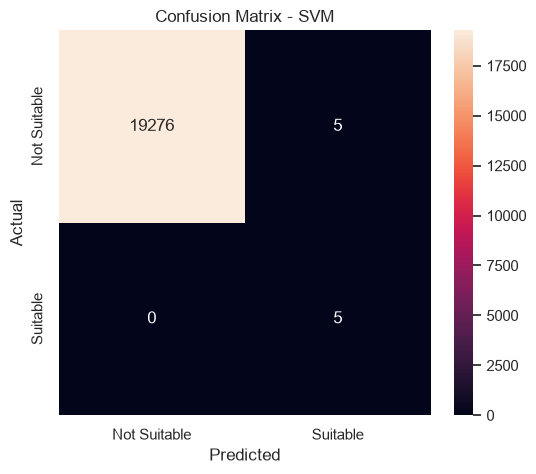

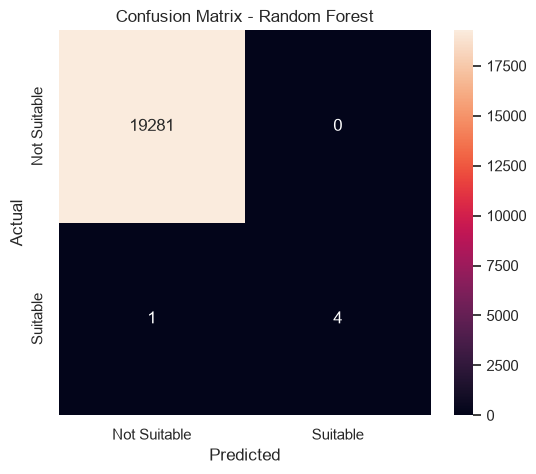

In [90]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=['Not Suitable', 'Suitable'],
        yticklabels=['Not Suitable', 'Suitable']
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

In [91]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='f1',
        n_jobs=-1
    )

    cv_results.append({
        'Model': name,
        'Mean F1': scores.mean(),
        'Std F1': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by='Mean F1',
    ascending=False
).reset_index(drop=True)

,Model,Mean F1,Std F1
0,Decision Tree,0.949206,0.063014
1,Random Forest,0.876190,0.122706
2,SVM,0.605501,0.038743
3,KNN,0.413333,0.223706
4,Logistic Regression,0.378437,0.040756


In [92]:
best_model_name = cv_results_df.loc[
    cv_results_df['Mean F1'].idxmax(),
    'Model'
]

print("Best Model:", best_model_name)

Best Model: Decision Tree


In [93]:
best_model = models[best_model_name]

print(best_model)

DecisionTreeClassifier(class_weight='balanced', random_state=42)
